Аналитические ветви (если существуют):
  Ветвь 1: 75.275753°
  Ветвь 2: 21.244048°

РЕЗУЛЬТАТЫ:
              Ньютон: alpha =  21.244048°, |f|=0.000e+00, iters=4, time=0.00 ms, ok=True
              Ньютон: alpha =  75.275753°, |f|=9.095e-13, iters=10, time=0.00 ms, ok=True
            Стрельба: alpha =  21.244048°, |r|=3.411e-13, iters=5, time=117.36 ms, ok=True


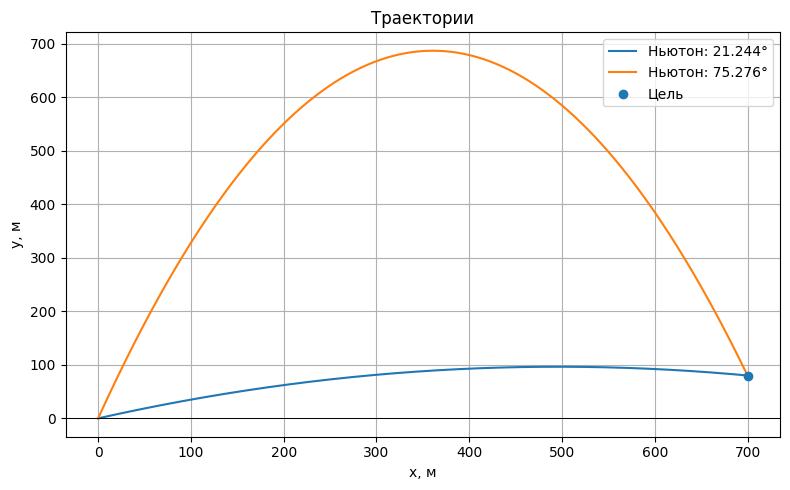

In [1]:
import numpy as np
import time
from math import sin, cos, tan
from dataclasses import dataclass
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp

# параметры
g = 9.81
v0 = 120.0
target = (700.0, 80.0)   # (x_T, y_T)
deg = np.degrees
rad = np.radians


def residual_analytic(alpha, v0, xT, yT):
    ca = np.cos(alpha)
    ta = np.tan(alpha)
    return xT * ta - (g * xT**2) / (2 * v0**2 * ca**2) - yT

def residual_analytic_derivative(alpha, v0, xT, yT):
    ca = np.cos(alpha)
    sa = np.sin(alpha)
    return xT / (ca**2) - (g * xT**2 * sa) / (v0**2 * ca**3)


@dataclass
class SolveResult:
    alpha: float
    iters: int
    fval: float
    elapsed: float
    ok: bool
    method: str

def newton_solver(alpha0, v0, xT, yT, tol=1e-12, max_iter=50):
    t0 = time.time()
    alpha = alpha0
    for k in range(1, max_iter+1):
        f = residual_analytic(alpha, v0, xT, yT)
        if abs(f) < tol:
            return SolveResult(alpha, k, f, time.time()-t0, True, "Ньютон")
        df = residual_analytic_derivative(alpha, v0, xT, yT)
        if df == 0 or not np.isfinite(df):
            break
        alpha = alpha - f/df
    return SolveResult(alpha, k, residual_analytic(alpha, v0, xT, yT), time.time()-t0, False, "Ньютон")


# Метод стрельбы:
def projectile_ode(t, Y):
    x, y, vx, vy = Y
    return [vx, vy, 0.0, -g]

def shoot_residual(alpha, v0, xT, yT):
    vx0 = v0 * np.cos(alpha)
    vy0 = v0 * np.sin(alpha)
    if vx0 <= 1e-12:
        return np.inf 
    Y0 = [0.0, 0.0, vx0, vy0]

    def hit_x(t, Y):
        return Y[0] - xT
    hit_x.terminal = True
    hit_x.direction = 1

    t_upper = max(2.0 * xT / vx0, 1.0)

    sol = solve_ivp(projectile_ode, [0.0, t_upper], Y0, events=hit_x, rtol=1e-9, atol=1e-12, max_step=t_upper/1000.0)
    if len(sol.t_events[0]) == 0:
        return np.inf
    y_hit = sol.y_events[0][0][1]
    return y_hit - yT

def shooting_secant(alpha0, alpha1, v0, xT, yT, tol=1e-9, max_iter=50):
    t0 = time.time()
    f0 = shoot_residual(alpha0, v0, xT, yT)
    f1 = shoot_residual(alpha1, v0, xT, yT)
    if not np.isfinite(f0) or not np.isfinite(f1):
        return SolveResult(np.nan, 0, np.nan, time.time()-t0, False, "Shooting (secant)")
    a0, a1 = alpha0, alpha1
    for k in range(1, max_iter+1):
        if f1 == f0:
            return SolveResult(a1, k, f1, time.time()-t0, False, "Стрельба")
        a2 = a1 - f1*(a1 - a0)/(f1 - f0)
        f2 = shoot_residual(a2, v0, xT, yT)
        if abs(f2) < tol:
            return SolveResult(a2, k, f2, time.time()-t0, True, "Стрельба")
        a0, f0, a1, f1 = a1, f1, a2, f2
    return SolveResult(a1, k, f1, time.time()-t0, False, "Стрельба")


def analytic_branches(v0, xT, yT):
    D = v0**4 - g*(g*xT**2 + 2*yT*v0**2)
    if D < 0:
        return []
    root = np.sqrt(D)
    t1 = (v0**2 + root)/(g*xT)
    t2 = (v0**2 - root)/(g*xT)
    alphas = []
    for t in (t1, t2):
        alphas.append(np.arctan(t))
    # убрать дубликаты (когда ветви совпадают)
    uniq = []
    for a in alphas:
        if not any(abs((a - b)) < 1e-12 for b in uniq):
            uniq.append(a)
    return uniq

# --------------------------
# траектория для графика
# --------------------------
def trajectory_points(alpha, v0, t_end=None, n=400):
    vx0 = v0 * np.cos(alpha)
    vy0 = v0 * np.sin(alpha)
    # если нужно ровно до xT — возьмем время долета до xT (в безсопр. случае известно точно)
    if t_end is None:
        t_end = target[0] / max(vx0, 1e-12)
    t = np.linspace(0.0, t_end, n)
    x = vx0 * t
    y = vy0 * t - 0.5 * g * t**2
    return x, y


# Сравнение

xT, yT = target

branches = analytic_branches(v0, xT, yT)
print("Аналитические ветви (если существуют):")
if not branches:
    print("  Нет действительных решений (дискриминант < 0).")
else:
    for i, a in enumerate(branches, 1):
        print(f"  Ветвь {i}: {deg(a):.6f}°")

# Ньютон: 
starts_deg = [20.0, 70.0] 
newton_results = []

for a0_deg in starts_deg:
    res = newton_solver(rad(a0_deg), v0, xT, yT, tol=1e-12, max_iter=50)
    newton_results.append(res)

# Стрельба
shoot_res = shooting_secant(rad(starts_deg[0]), rad(starts_deg[1]), v0, xT, yT, tol=1e-9, max_iter=50)

print("\nРЕЗУЛЬТАТЫ:")
for r in newton_results:
    print(f"{r.method:>20s}: alpha = {deg(r.alpha):10.6f}°, |f|={abs(r.fval):.3e}, iters={r.iters}, time={r.elapsed*1e3:.2f} ms, ok={r.ok}")
print(f"{shoot_res.method:>20s}: alpha = {deg(shoot_res.alpha):10.6f}°, |r|={abs(shoot_res.fval):.3e}, iters={shoot_res.iters}, time={shoot_res.elapsed*1e3:.2f} ms, ok={shoot_res.ok}")

# --------------------------
# визуализация
# --------------------------
plt.figure(figsize=(8,5))
drawn = []
for r in newton_results:
    if r.ok:
        x,y = trajectory_points(r.alpha, v0)
        plt.plot(x, y, label=f"Ньютон: {deg(r.alpha):.3f}°")
        drawn.append(r.alpha)

if shoot_res.ok and (len(drawn)==0 or all(abs(shoot_res.alpha - a) > rad(0.05) for a in drawn)):
    x,y = trajectory_points(shoot_res.alpha, v0)
    plt.plot(x, y, '--', label=f"Стрельба (секущая): {deg(shoot_res.alpha):.3f}°")

plt.scatter([xT], [yT], marker='o', zorder=5, label="Цель")
plt.axhline(0, lw=0.7, color='k')
plt.xlabel("x, м")
plt.ylabel("y, м")
plt.title("Траектории")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()
